## 1. 환경설정

In [ ]:
import os  # 파일 경로 설정용 모듈
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns
import time
import warnings
import ast
from collections import OrderedDict
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score
warnings.filterwarnings("ignore")
pd.set_option('display.max_colwidth', None)

In [ ]:
!pip install koreanize_matplotlib -q

## 2. 데이터 불러오기

In [ ]:
# CSV 저장된 폴더 경로
csv_folder = r'C:\Users\user\Desktop\DA_6\고급프로젝트\cleaned_data'

# DataFrame들을 담을 딕셔너리
df_dict = {}

# 반복문으로 모든 CSV 불러오기
for filename in os.listdir(csv_folder):
    if filename.endswith('.csv'):
        table_name = filename.replace('.csv', '')
        df = pd.read_csv(os.path.join(csv_folder, filename))
        df_dict[table_name] = df
        print(f"✅ 불러옴: {table_name} → {df.shape}")

✅ 불러옴: accounts_attendance → (349632, 3)
✅ 불러옴: accounts_blockrecord → (19482, 5)
✅ 불러옴: accounts_failpaymenthistory → (162, 5)
✅ 불러옴: accounts_friendrequest → (17146846, 6)
✅ 불러옴: accounts_group → (84501, 4)
✅ 불러옴: accounts_nearbyschool → (53219, 4)
✅ 불러옴: accounts_paymenthistory → (94608, 5)
✅ 불러옴: accounts_pointhistory → (2318234, 5)
✅ 불러옴: accounts_school → (5491, 4)
✅ 불러옴: accounts_timelinereport → (206, 6)
✅ 불러옴: accounts_user → (226360, 14)
✅ 불러옴: accounts_userquestionrecord → (1207863, 12)
✅ 불러옴: accounts_userwithdraw → (70281, 3)
✅ 불러옴: accounts_user_contacts → (5063, 4)
✅ 불러옴: device_properties → (234528, 4)
✅ 불러옴: events → (3, 6)
✅ 불러옴: event_receipts → (309, 5)
✅ 불러옴: hackle_events → (11329837, 11)
✅ 불러옴: hackle_properties → (334091, 8)
✅ 불러옴: polls_question → (3902, 3)
✅ 불러옴: polls_questionpiece → (1255307, 5)
✅ 불러옴: polls_questionreport → (50938, 5)
✅ 불러옴: polls_questionset → (148539, 6)
✅ 불러옴: polls_usercandidate → (4441664, 4)
✅ 불러옴: user_properties → (230812, 5)


In [ ]:
# 딕셔너리 안에 있는 테이블들 개별 변수 할당
for name, df in df_dict.items():
    globals()[name] = df

## 3. 유저 행동 흐름 분석

### 3-1. 전환 분석

In [ ]:
# 핵클 프로퍼티스 테이블 유저 수
hackle_properties['user_id'].nunique()

230853

In [ ]:
# 1. session_id 기준으로 user_id join
events_merged = hackle_events.merge(
    hackle_properties[['session_id', 'user_id']],
    on='session_id',
    how='left'  # left join: 이벤트 기준
)

# 2. user_id 기준으로 event 흐름 리스트화
flow_df = (
    events_merged[['user_id', 'event_key', 'event_datetime']]
    .sort_values(['user_id', 'event_datetime'])
    .groupby('user_id')
    .agg({'event_key': list})
    .reset_index()
)

flow_df.tail()
# 이벤트 테이블에 있는 유저 수 : 230,757명

,user_id,event_key
230752,1579928,"[$session_start, launch_app, view_signup, view_signup, view_signup, view_signup, launch_app, view_signup, view_signup, view_signup, view_signup, view_signup, view_signup, $session_end, $session_start, complete_signup, click_bottom_navigation_lab, view_lab_tap, view_timeline_tap, view_profile_tap, view_lab_tap, view_profile_tap, view_lab_tap, view_profile_tap, view_lab_tap, view_profile_tap, view_lab_tap, view_timeline_tap, view_lab_tap, view_timeline_tap, view_lab_tap, view_questions_tap, click_bottom_navigation_questions, view_timeline_tap, click_bottom_navigation_timeline, view_timeline_tap, click_question_ask, click_bottom_navigation_lab, view_lab_tap, click_bottom_navigation_lab, click_bottom_navigation_profile, view_profile_tap, click_bottom_navigation_lab, view_lab_tap, view_questions_tap, view_timeline_tap, click_bottom_navigation_questions, click_bottom_navigation_lab, click_bottom_navigation_profile, view_timeline_tap, view_lab_tap]"
230753,1579929,"[$session_start, launch_app, launch_app, view_signup, view_signup, view_signup, view_signup, view_signup, view_signup, $session_end, $session_start, complete_signup, click_question_start, skip_question, complete_question, click_attendance, view_shop, click_bottom_navigation_timeline, view_timeline_tap, click_bottom_navigation_timeline, click_bottom_navigation_timeline, click_random_ask_normal, click_random_ask_shuffle, click_random_ask_shuffle, click_random_ask_shuffle, click_random_ask_shuffle, click_random_ask_shuffle, click_random_ask_shuffle, click_random_ask_shuffle, click_random_ask_shuffle, click_random_ask_shuffle, click_random_ask_shuffle, click_random_ask_shuffle, view_lab_tap, click_bottom_navigation_lab, click_bottom_navigation_profile, view_profile_tap, click_profile_ask, click_appbar_chat_rooms, click_appbar_alarm_center, click_bottom_navigation_timeline, click_question_ask, view_timeline_tap, view_lab_tap, view_questions_tap, click_bottom_navigation_questions, click_question_ask, view_lab_tap, click_bottom_navigation_lab, view_timeline_tap, click_bottom_navigation_questions, view_timeline_tap, view_questions_tap, $session_end, launch_app, $session_start, view_profile_tap, click_bottom_navigation_profile, view_timeline_tap, click_bottom_navigation_profile, click_appbar_friend_plus, click_appbar_chat_rooms, view_lab_tap, click_bottom_navigation_questions, view_timeline_tap, view_questions_tap, click_bottom_navigation_timeline, view_timeline_tap, view_questions_tap, click_bottom_navigation_questions, click_question_open, click_bottom_navigation_profile, view_lab_tap, view_timeline_tap, view_profile_tap, $session_end]"
230754,1579930,"[$session_start, launch_app, view_signup, view_signup, view_signup, view_signup, view_signup, view_signup, $session_end, $session_start, complete_signup, view_shop, click_purchase, view_timeline_tap, click_bottom_navigation_profile, view_lab_tap, view_profile_tap, view_timeline_tap, view_lab_tap, click_bottom_navigation_timeline, view_lab_tap, view_profile_tap, click_bottom_navigation_lab, view_lab_tap, view_timeline_tap, click_bottom_navigation_questions, view_questions_tap, click_appbar_chat_rooms, $session_end]"
230755,1579931,"[launch_app, $session_start, view_signup, view_signup, view_signup, view_signup, view_signup, view_signup, $session_end, $session_start, complete_signup]"
230756,1579932,"[$session_start, launch_app, view_signup, view_signup, view_signup, view_signup, view_signup, view_signup, $session_end, complete_signup, $session_start, view_timeline_tap, click_bottom_navigation_profile, view_lab_tap, view_profile_tap, view_questions_tap, view_lab_tap, view_timeline_tap, click_bottom_navigation_questions, click_bottom_navigation_timeline, view_timeline_tap, view_lab_tap, click_bottom_navigation_lab, click_question_ask, view_profile_tap, click_bottom_navigation_profile, view_questions_tap, view_lab_tap, view_timeline_tap, click_bottom_navigation_questions, launch_app, click_appbar_frie

In [ ]:
# 전환 이벤트만 필터링한 이벤트 흐름 리스트
conversion_events = [
    'complete_signup',
    'click_question_start', 'click_question_ask', 'click_random_ask_normal',
    'complete_question',
    'click_purchase', 'complete_purchase',
    'skip_question'
]

# 필터링된 이벤트 흐름
filtered_flow_df = (
    events_merged[events_merged['event_key'].isin(conversion_events)]
    .sort_values(['user_id', 'event_datetime'])
    .groupby('user_id')
    .agg({'event_key': list})
    .reset_index()
)

- 전환 이벤트 선정 기준

1. coplete_signup
    - 유저가 회원으로 전환되는 최초 진입점
    - 전환 분석의 시작점으로 포함

2. 질문 관련 행동
    - 유저가 서비스의 핵심 기능(질문/참여)에 얼마나 관여했나를 보기 위함
    - click_question_start (홈에서 질문 시작) -> click_question_ask (ask 버튼 클릭) -> click_random_ask_narmal (기존 ask 목록에서 일반 질문 클릭) -> complete_question (질문 완료)
    - 서비스 핵심 사용 여부와 이탈 위치를 확인하기 위한 주요 중간 단계

3. 결제 관련 이벤트
    - click_purchase : 결제를 의도한 행동
    - complete_purchase : 결제 완료
    - 유료 기능에 대한 사용 시도는 주요 행동으로 간주
    - 다만, 본 서비스가 10대 중심 익명 투표 앱이므로 결제를 최종 전환으로 정의하지는 않음

- 전환 이벤트 비선정 이유

1. 앱/탭 진입 관련 이벤트 (예: view_home_tap, view_question_tap, launch_app, $session_start, $session_end)
    - 앱 구조상 자연 발생하는 pass-through 이벤트가 많음
    - 대부분 자동 혹은 수동 진입 시 발생하는 이벤트
    - 실제 행동 의도가 분명하지 않아서 전환 흐름 판단에 노이즈 가능성 있어 제외

2. UI 클릭/탐색 계열 (예: click_appbar_chat_rooms, click_notice, click_invite_friend, ...)
    - 알림, 친구 초대 등은 서비스 이용을 보조하거나 탐색 중 발생하는 클릭
    - 이 자체가 목적이 아닌 경우가 많아서 전환 퍼널 핵심 흐름으로 보기엔 부적절하다고 판단

In [ ]:
# 전환 자동 태깅: 회원가입 → 질문 시작 흐름이 발생한 유저를 '전환 유저'로 정의
# 여기서 전환 기준은 complete_signup 후 click_question_start 이벤트가 시간 순서대로 발생한 경우
# 이는 유저가 서비스 핵심 기능(질문 작성)에 도달한 '아하 모먼트'로 해석

def contains_conversion(events, sequence):
    i = 0
    for event in events:
        if event == sequence[i]:
            i += 1
        if i == len(sequence):
            return True
    return False

# 전환 이벤트 정의: 회원가입 → 질문 시작
signup_to_question_event = ['complete_signup', 'click_question_start']

# 유저 이벤트 흐름에 전환 퍼널이 포함되어 있는지 확인하여 is_converted 컬럼 생성
filtered_flow_df['is_converted'] = filtered_flow_df['event_key'].apply(
    lambda x: contains_conversion(x, signup_to_question_event)
)

In [ ]:
# 전환 이벤트키를 갖고 있는 총 유저 수 114,099명
# 완전히 passive한 유저 (예: 앱만 실행하고 아무것도 안 한 유저)나 퍼널 외 이벤트만 한 유저는 제외
filtered_flow_df

,user_id,event_key,is_converted
0,833303,"[click_question_ask, click_question_ask, click_question_ask, click_question_ask]",False
1,833525,"[click_question_ask, click_question_ask]",False
2,834089,"[click_question_ask, click_question_ask, click_question_ask, click_question_ask, click_question_ask, click_question_ask]",False
3,834325,"[click_question_start, click_question_ask]",False
4,835683,"[click_question_ask, click_question_ask, click_question_ask, click_question_start]",False
...,...,...,...
114094,1579928,"[complete_signup, click_question_ask]",False
114095,1579929,"[complete_signup, click_question_start, skip_question, complete_question, click_random_ask_normal, click_question_ask, click_question_ask]",True
114096,1579930,"[complete_signup, click_purchase]",False
114097,1579931,[complete_signup],False


In [ ]:
# 아하 모먼트를 갖고 있는 유저 (총 517명)
filtered_flow_df[filtered_flow_df['is_converted'] == True]

,user_id,event_key,is_converted
113155,1578957,"[complete_signup, complete_signup, click_question_start, click_question_start, click_question_start, click_question_start, skip_question, skip_question, skip_question, skip_question, complete_question, complete_question, click_question_start, click_question_start, skip_question, skip_question, skip_question, skip_question, complete_question, complete_question, click_question_start, click_question_start, complete_question, complete_question, click_question_start, click_question_start, skip_question, skip_question, complete_question, complete_question, click_question_start, click_question_start, skip_question, skip_question, complete_question, complete_question, click_question_start, click_question_start, complete_question, complete_question, click_question_start, click_question_start, skip_question, skip_question, complete_question, complete_question, click_question_start, click_question_start, skip_question, skip_question, skip_question, skip_question, skip_question, skip_question, complete_question, complete_question]",True
113157,1578959,"[complete_signup, complete_signup, click_question_start, click_question_start, skip_question, skip_question, skip_question, skip_question, complete_question, complete_question]",True
113158,1578960,"[complete_signup, complete_signup, complete_signup, click_question_ask, click_question_ask, click_question_ask, click_question_ask, click_question_ask, click_question_ask, click_question_ask, click_question_ask, click_question_ask, click_question_ask, click_question_ask, click_question_ask, click_question_start, click_question_start, click_question_start, skip_question, skip_question, skip_question, skip_question, skip_question, skip_question, complete_question, complete_question, complete_question, click_question_ask, click_question_ask, click_question_ask, click_question_start, click_question_start, click_question_start, click_question_start, click_question_start, click_question_start, skip_question, skip_question, skip_question, skip_question, skip_question, skip_question, complete_question, complete_question, complete_question, click_question_ask, click_question_ask, click_question_ask, click_question_start, click_question_start, click_question_start, skip_question, skip_question, skip_question, complete_question, complete_question, complete_question, click_question_start, click_question_start, click_question_start, complete_question, complete_question, complete_question, click_question_start, click_question_start, click_question_start, complete_question, complete_question, complete_question, click_question_start, click_question_start, click_question_start, click_question_start, click_question_start, click_question_start, click_question_start, click_question_start, click_question_start, complete_question, complete_question, complete_question, click_question_start, click_question_start, click_question_start, click_question_start, click_question_start, click_question_start, complete_question, complete_question, complete_question, click_question_start, click_question_start, click_question_start, complete_question, complete_question, complete_question, click_question_start, click_question_start, click_question_start, click_question_start, ...]",True
113159,1578961,"[complete_signup, complete_signup, click_question_start, click_question_start, skip_question, skip_question, complete_question, complete_question, skip_question, skip_question, click_question_ask, click_question_ask, click_question_ask, click_question_ask, click_question_ask, click_question_ask, click_question_ask, click_question_ask, click_question_ask, click_question_ask, click_question_start, click_question_start, skip_question, skip_question, skip_question, skip_question, skip_question, skip_question, skip_question, skip_question, complete_question, complete_question, click_purchase, click_purchase, click_purchase, click_purchase, click_purchase, click_purchase, click_purchase, click

In [ ]:
# 전환 이벤트를 한 번도 안 한 유저
all_users = events_merged['user_id'].unique()
conversion_users = filtered_flow_df['user_id'].unique()
non_conversion_users = set(all_users) - set(conversion_users)

len(non_conversion_users)

116658

### 3-2. 이탈 지점 분석

#### a. 전체 유저 이탈

In [ ]:
# 1. 마지막 이벤트 추출
flow_df['last_event'] = flow_df['event_key'].apply(lambda x: x[-1] if x else None)

# 2. 이탈 지점 분포 확인
total_exit_point_counts = flow_df['last_event'].value_counts().reset_index()
total_exit_point_counts.columns = ['event', 'user_count']

In [ ]:
total_exit_point_counts

,event,user_count
0,$session_start,28733
1,launch_app,21381
2,click_question_open,21125
3,click_bottom_navigation_profile,18854
4,view_lab_tap,18110
5,view_timeline_tap,16875
6,view_profile_tap,15629
7,click_bottom_navigation_questions,12676
8,click_notice_detail,12549
9,view_questions_tap,8475


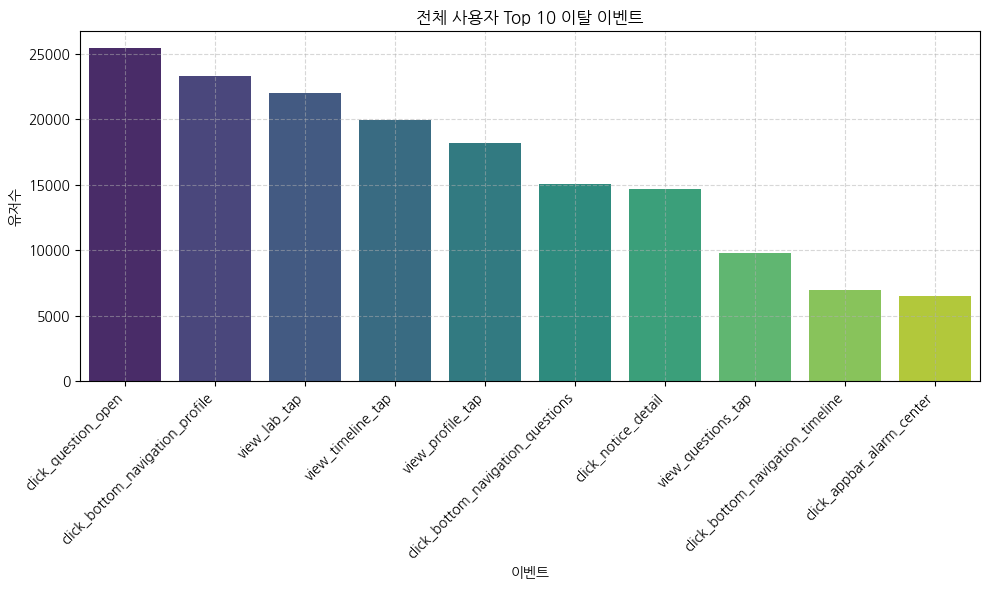

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=total_exit_point_counts.head(10),
    x='event',
    y='user_count',
    palette='viridis'
)

plt.title('전체 사용자 Top 10 이탈 이벤트')
plt.xlabel('이벤트')
plt.ylabel('유저수')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(linestyle='--', alpha=0.5)
plt.show()


In [ ]:
total_exit_point_counts['user_count'].sum()

230757

#### b. 전환 이벤트 유저 이탈

In [ ]:
# 1. 마지막 이벤트 추출
filtered_flow_df['last_event'] = filtered_flow_df['event_key'].apply(lambda x: x[-1] if x else None)

# 2. 이탈 지점 분포 확인
filtered_exit_point_counts = filtered_flow_df['last_event'].value_counts().reset_index()
filtered_exit_point_counts.columns = ['event', 'user_count']

In [ ]:
filtered_exit_point_counts

,event,user_count
0,click_question_ask,46619
1,complete_question,31342
2,click_question_start,20248
3,skip_question,7682
4,click_random_ask_normal,5426
5,click_purchase,1857
6,complete_purchase,707
7,complete_signup,218


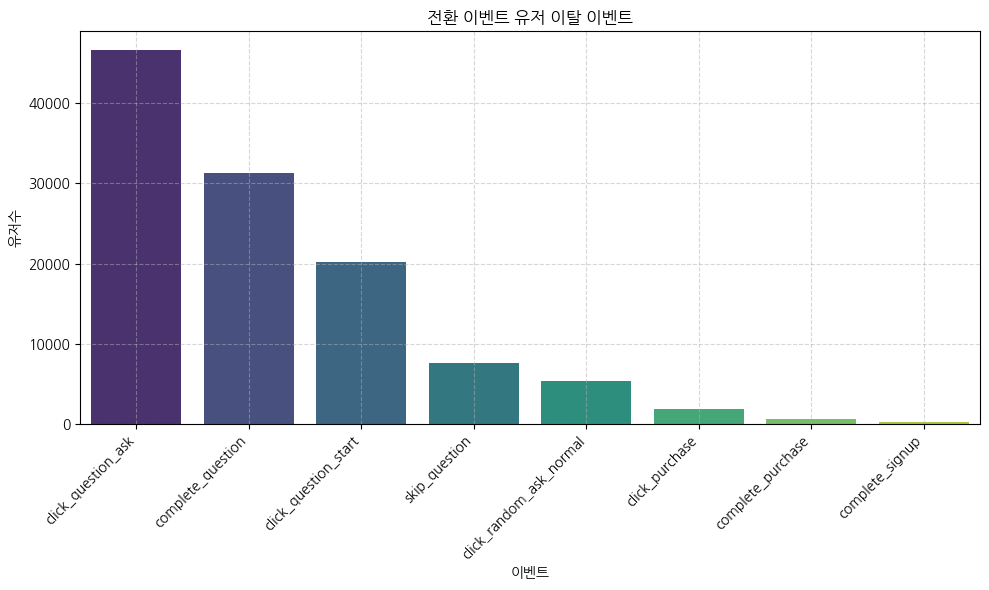

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=filtered_exit_point_counts,
    x='event',
    y='user_count',
    palette='viridis'
)

plt.title('전환 이벤트 유저 이탈 이벤트')
plt.xlabel('이벤트')
plt.ylabel('유저수')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(linestyle='--', alpha=0.5)
plt.show()


In [ ]:
filtered_exit_point_counts['user_count'].sum()

114099

### 3-3. 유입 후 첫 행동

In [ ]:
signup_event = 'complete_signup'

# 회원가입 이벤트가 포함된 유저만 추출
signup_users = flow_df[flow_df['event_key'].apply(lambda x: signup_event in x)].copy()

print(f"회원가입을 한 유저 수: {len(signup_users):,}명")

회원가입을 한 유저 수: 941명


In [ ]:
# 회원가입 후 첫 행동
signup_event = 'complete_signup'

def get_first_action_after_signup(events):
    """
    회원가입 이후 첫 번째 행동을 반환
    """
    if signup_event not in events:
        return None  # 회원가입 안 한 유저

    signup_idx = events.index(signup_event)

    # 회원가입 이후 첫 번째 이벤트 반환
    if signup_idx + 1 < len(events):
        return events[signup_idx + 1]
    return None

# 첫 행동 추출
flow_df['first_action_after_signup'] = flow_df['event_key'].apply(get_first_action_after_signup)

# 빈도 집계
first_action_counts = flow_df['first_action_after_signup'].value_counts(dropna=False)

print(first_action_counts)

first_action_after_signup
None                                 229838
$session_start                          328
complete_signup                         201
view_timeline_tap                       102
click_bottom_navigation_questions        52
click_question_start                     52
click_bottom_navigation_timeline         36
view_lab_tap                             32
launch_app                               26
click_bottom_navigation_profile          21
click_bottom_navigation_lab              14
click_appbar_chat_rooms                  10
view_profile_tap                          9
click_question_ask                        9
$session_end                              7
view_login                                6
click_attendance                          6
click_appbar_friend_plus                  3
click_appbar_alarm_center                 2
click_invite_friend                       1
view_signup                               1
view_shop                                 1
Name: 

In [ ]:
# 회원가입 후 첫 번째 핵심 행동
# 분석 기준 이벤트 정의
signup_event = 'complete_signup'
core_actions = [
    'click_question_start',
    'click_question_ask',
    'click_vote'
]  # 핵심 행동 후보

def get_first_core_action(events):
    """
    회원가입 이벤트 이후의 첫 핵심 행동을 반환
    """
    if signup_event not in events:
        return None  # 회원가입 안 한 유저

    signup_idx = events.index(signup_event)

    # 회원가입 이후 이벤트 순회
    for e in events[signup_idx+1:]:
        if e in core_actions:
            return e
    return None  # 핵심 행동 없음

# 새로운 컬럼 추가
flow_df['first_core_action'] = flow_df['event_key'].apply(get_first_core_action)

# 첫 핵심 행동 분포 보기
flow_df['first_core_action'].value_counts(dropna=False)


first_core_action
None                    230040
click_question_start       372
click_question_ask         345
Name: count, dtype: int64

- 회원가입을 한 유저들의 수가 너무너무 적음 -> 퍼널 첫 행동으로 정의하기엔 부적절
- 회원가입이 아닌 앱 실행 후 첫 행동 보기
- 의미 없는 행동인 session 관련 행위들, 앱 실행 등 제외

In [ ]:
# 무시할 초기 이벤트
ignore_events = ['$session_start', '$session_end', 'launch_app']

def get_first_meaningful_action(events):
    for e in events:
        if e not in ignore_events:
            return e
    return None

flow_df['first_meaningful_action'] = flow_df['event_key'].apply(get_first_meaningful_action)

# 빈도 집계
first_action_counts = flow_df['first_meaningful_action'].value_counts(dropna=False)

print(first_action_counts.head(20))

first_meaningful_action
click_bottom_navigation_questions    39854
click_appbar_alarm_center            30258
click_question_open                  25102
view_login                           22571
view_timeline_tap                    21068
None                                 21048
click_bottom_navigation_timeline     13557
click_question_start                 10931
view_lab_tap                          9137
click_attendance                      6828
click_appbar_chat_rooms               6547
click_bottom_navigation_profile       5854
view_signup                           4317
click_bottom_navigation_lab           3942
view_home_tap                         2996
click_question_ask                    2751
view_profile_tap                      1517
click_question_share                   858
click_appbar_friend_plus               520
view_shop                              489
Name: count, dtype: int64


### 3-4. 행동 경로

In [ ]:
# 1. user_id별 + 시간순으로 정렬
df_sorted = events_merged.sort_values(['user_id', 'event_datetime'])

# 2. user_id별 이벤트 순서 리스트 만들기
# 중복 제거 후 순서만 유지
event_sequence = df_sorted.groupby('user_id')['event_key'].apply(lambda x: list(dict.fromkeys(x))).reset_index()

# 3. 확인
print(event_sequence.head())

   user_id  \
0   831962   
1   832340   
2   833041   
3   833202   
4   833203   

                                                                                                                                                                                                                                                                                                                                                                                                              event_key  
0                                                                                                                                                                                                                                                                                    [launch_app, $session_start, $session_end, view_login, click_bottom_navigation_lab, view_lab_tap, click_bottom_navigation_profile]  
1                                                                                              

In [ ]:
# 1. 제외 이벤트 제거
df_filtered = df_sorted[~df_sorted['event_key'].isin(ignore_events)]

# 2. user_id별 이벤트 순서 만들기 (중복 제거 O)
event_sequence = (
    df_filtered.groupby('user_id')['event_key']
    .apply(lambda x: list(dict.fromkeys(x)))  # 순서 유지 + 중복 제거
    .reset_index()
)

# 3. 경로를 문자열로 변환
event_sequence['path'] = event_sequence['event_key'].apply(lambda x: " → ".join(x))

# 4. 경로별 빈도 계산
path_counts = (
    event_sequence['path']
    .value_counts()
    .reset_index()
    .rename(columns={'index': 'path', 'path': 'count'})
)

# 5. 상위 N개 경로 보기
top_n = 10
print(path_counts.head(top_n))

                                                                                 count  \
0                                                                  click_question_open   
1                                      click_appbar_alarm_center → click_notice_detail   
2                                                    click_bottom_navigation_questions   
3                              click_bottom_navigation_questions → click_question_open   
4                                                            click_appbar_alarm_center   
5                                                                 click_question_start   
6  click_bottom_navigation_questions → click_appbar_alarm_center → click_notice_detail   
7                                                     view_login → click_question_open   
8                click_question_open → click_appbar_alarm_center → click_notice_detail   
9                                                                           view_login   

   count 

- 행동 분석
    - click_question_open, click_bottom_navigation_questions, click_appbar_alarm_center 등의 비중이 높은 첫 행동
    - 유저들은 처음에 질문 탭/알림을 탐색하며 “관찰자”로 시작
`
- 결론:
    - “유입 후 탐색 흐름” 분석에 적합한 데이터
    - 유저 유형(탐험가, 관찰자 등) 클러스터링으로 넘어가기에 좋음

- 전환 정의 변경 필요
    - 회원가입 -> 질문 시작 -> 질문 작성 -> 결제 시도 ---> 부적절
    - 데이터상 대부분 기존 유저, 가입 유저 매우 적음
    - 질문 작성 or 질문 열람이 전환에 가깝게 사용됨
    - view_login -> click_question_open (or click_question_start)
    - click_bottom_navigation_questions -> click_question_start
    - view_question -> click_vote -> click_purchase

- 퍼널은 의미 없음 (신규 유저 샘플 너무 적음)
- 첫 행동 -> 재방문 여부 리텐션 지표로 삼는게 더 유효할 가능성 o

#### a. 유저별 재방문 여부

In [ ]:
# 0) 원본 이벤트 시간 컬럼을 먼저 datetime으로
events_merged['event_datetime'] = pd.to_datetime(
    events_merged['event_datetime'], errors='coerce'
)

# 1. 유저별 첫 방문일(첫 이벤트 발생일) 추출
user_first_date = events_merged.groupby('user_id')['event_datetime'].min().reset_index()
user_first_date.rename(columns={'event_datetime': 'first_visit_date'}, inplace=True)

# 2. 전체 이벤트 데이터에 첫 방문일 병합
events_with_first = events_merged.merge(user_first_date, on='user_id', how='left')

# 날짜 컬럼 datetime 타입으로 명확하게 변환
events_merged['event_datetime'] = pd.to_datetime(events_merged['event_datetime'])
user_first_date['first_visit_date'] = pd.to_datetime(user_first_date['first_visit_date'])

# 3. 유저별 각 이벤트가 첫 방문일로부터 며칠 후인지 계산
events_with_first['days_since_first'] = (
    (events_with_first['event_datetime'] - events_with_first['first_visit_date']).dt.days
)

# 4. 1일차(첫 방문 다음 날)에 다시 방문한 유저 추출
retention_day_1 = events_with_first[
    events_with_first['days_since_first'] == 1
]['user_id'].unique()

# 5. 유저별 first_meaningful_action 가져오기 (사전 계산된 flow_df 기준)
first_action_df = flow_df[['user_id', 'first_meaningful_action']].copy()

# 6. 유저가 1일차에 재방문했는지 여부를 True/False로 표시
first_action_df['retained_day_1'] = first_action_df['user_id'].isin(retention_day_1)

# 7. first_action별 전체 유저 수 및 리텐션 유저 수 집계
retention_by_action = (
    first_action_df.groupby('first_meaningful_action')['retained_day_1']
    .agg(['count', 'sum'])  # count: 전체 유저 수, sum: 재방문 유저 수
    .rename(columns={'count': 'total_users', 'sum': 'retained_users'})
)

# 8. 리텐션율 계산 (재방문 유저 수 / 전체 유저 수)
retention_by_action['retention_rate'] = (
    retention_by_action['retained_users'] / retention_by_action['total_users']
)

# 9. 결과 확인 (리텐션 높은 기준)
print(retention_by_action.sort_values('retention_rate', ascending=False))

                                   total_users  retained_users  retention_rate
first_meaningful_action                                                       
click_friend_invite                          3               3        1.000000
skip_question                               13              10        0.769231
complete_question                            8               6        0.750000
click_random_ask_other                      16               7        0.437500
click_random_ask_shuffle                    15               6        0.400000
click_attendance                          6828            2583        0.378295
click_random_ask_normal                     34              10        0.294118
click_question_share                       858             221        0.257576
view_signup                               4317            1018        0.235812
view_login                               22571            4478        0.198396
click_question_start                     10931      

In [ ]:
# 리텐션 유저 수(절대 수) 많은 기준
print(retention_by_action.sort_values('retained_users', ascending=False))

                                   total_users  retained_users  retention_rate
first_meaningful_action                                                       
view_login                               22571            4478        0.198396
click_question_open                      25102            4059        0.161700
click_bottom_navigation_questions        39854            3914        0.098208
click_appbar_alarm_center                30258            3567        0.117886
click_attendance                          6828            2583        0.378295
click_question_start                     10931            2109        0.192938
view_timeline_tap                        21068            1961        0.093080
click_bottom_navigation_timeline         13557            1698        0.125249
view_lab_tap                              9137            1405        0.153770
view_signup                               4317            1018        0.235812
click_appbar_chat_rooms                   6547      

1. view_login 리텐션 유저 수 1위 (4,478명)
    - 로그인 후 지속 사용한 유저로 해석 가능?
        - 로그인 이후 무엇을 했는지 흐름 분석 중요 -> 로그인 이후 첫 행동

2. click_question_open, click_question_start 리텐션 유의미
    - 핵심 긴으 접근과 연결된 이벤트
    - 참여형 행동을 한 유저는 리텐션 뚜렷 (종합 기준 상위)
        - click_question_open -> 피드 탐색형 유저
        - click_question_start -> 참유 유저
        -> 클러스터링 기반 행동 유형 분류 시 중요한 기준점

3. click_attendance 리텐션율 최상위권
    - 비율(37.8%)로 보면 가장 우수한 리텐션 행동 ㅈ우 하나
    - 유저 수는 중간이지만 명확한 "유지 기여" 행동이라고 볼 수 있음
        - 이 기능을 첫 진입 타이밍에 노출하는 A/B 테스트 설계 고려
        - 첫 방문 시 출석 유도 메시지 vs 미노출 그룹 비교

4. 리텐션율은 낮지만 유저 수가 많은 행동
    - click_bottom_navigation_questions: 39,854명, 리텐션율 9.8%
    - view_timeline_tap: 21,068명, 리텐션율 9.3%
        - 이 행동으로 유입되지만 유지율 낮음
        - 탐색 후 참여 없이 이탈하는 흐름
        - 이런 유저군은 참여 전환 유도 전략 필요 (예: 튜토리얼, 첫 질문 푸시 등)

|유형|행동 예시|특징|전략|
|----|-----|-----|----|
|참여형(고리텐션)|click_attendance, click_question_start|리텐션율 높고, 액션 중심|첫 방문 시 적극 유도|
|탐색형(저리텐션)|click_bottom_navigation_question, view_timeline_tap|유입 많지만 이탈 많음|참여 유도 (온보딩 개선 등)|
|핵심 진입형|view_login, click_question_open|리텐션 유저 수 많음|로그인 이후 동선 최적화 필요|

#### b. view_login 이후 행동

In [ ]:
# 1. view_login을 첫 meaningful action으로 가진 유저만 필터링
login_users = flow_df[flow_df['first_meaningful_action'] == 'view_login']['user_id']

# 2. 이 유저들의 전체 이벤트 로그 가져오기
login_user_events = events_merged[events_merged['user_id'].isin(login_users)].copy()

# 3. event_datetime 기준으로 유저별 이벤트 정렬
login_user_events.sort_values(['user_id', 'event_datetime'], inplace=True)

# 4. 유저별로 view_login이 나온 이후의 첫 번째 다음 행동을 추출
def get_action_after_login(events):
    """
    이벤트 리스트 중 view_login이 여러 번 반복될 경우를 고려하여,
    view_login 이후 처음으로 등장하는 다른 meaningful action을 반환
    """
    try:
        login_idx = events.index('view_login')

        # 이후 이벤트 중 'view_login'을 제외하고 처음 등장하는 다른 행동 찾기
        for e in events[login_idx + 1:]:
            if e not in ['view_login', '$session_start', '$session_end', 'launch_app']:
                return e
        return None  # 끝까지 meaningful action이 없을 경우
    except ValueError:
        return None  # view_login이 없을 경우

# 5. 유저별 이벤트 시퀀스 리스트로 변환
user_event_seq = (
    login_user_events
    .sort_values(['user_id', 'event_datetime'])
    .groupby('user_id')['event_key']
    .apply(list)
    .reset_index()
)

# 6. 각 유저의 view_login 다음 행동 파악
user_event_seq['action_after_login'] = user_event_seq['event_key'].apply(get_action_after_login)

# 7. 분포 확인: 로그인 다음 행동으로 무엇이 가장 많았는지
action_counts = user_event_seq['action_after_login'].value_counts(dropna=False)

# 8. 결과 출력
print("view_login 이후 첫 행동 분포 (상위 20개):")
print(action_counts.head(20))


view_login 이후 첫 행동 분포 (상위 20개):
action_after_login
click_bottom_navigation_questions    4781
click_question_open                  4772
click_appbar_alarm_center            3872
view_timeline_tap                    2617
click_bottom_navigation_timeline     1390
click_question_start                 1109
view_lab_tap                          931
click_appbar_chat_rooms               797
click_bottom_navigation_profile       588
None                                  376
click_bottom_navigation_lab           373
click_attendance                      372
click_question_ask                    234
view_profile_tap                      168
view_questions_tap                     67
view_signup                            56
click_appbar_friend_plus               42
view_shop                              11
click_notice_detail                     5
click_random_ask_normal                 3
Name: count, dtype: int64


1. 탐색 행동 많지만, 참여 행동도 상당히 나타남
    - click_question_start (질문 시작): 1,109명 -> 꽤 많은 유저가 로그인 후 바로 참여
    - click_attendance (출석): 372명 -> 이탈율 낮고 리텐션율 높았던 행동

2. None: 376명
    - view_login 이후 아무 meaninful action 없이 이탈한 유저 존재
    - 비율로 보면 크게 문제 되진 않음

3. 상위 3개 행동만으로도 약 1.6만 명 커버
    - click_question_open, click_bottom_navigation_questions, click_appbar_alarm_center
    - 이들을 중심으로 초기 전환 유도 전략 설계 가능

#### c. first_action별 3일차/7일차 리텐션 비교

In [ ]:
# 1. 3일차, 7일차에 방문한 유저 ID 추출
retention_day_3 = events_with_first[events_with_first['days_since_first'] == 3]['user_id'].unique()
retention_day_7 = events_with_first[events_with_first['days_since_first'] == 7]['user_id'].unique()

# 2. flow_df에서 first_meaningful_action 가져오기
retention_df = flow_df[['user_id', 'first_meaningful_action']].copy()

# 3. 각 리텐션 기준별 컬럼 생성 (True/False)
retention_df['retained_day_3'] = retention_df['user_id'].isin(retention_day_3)
retention_df['retained_day_7'] = retention_df['user_id'].isin(retention_day_7)

# 4. action별 리텐션율 계산
retention_summary = (
    retention_df
    .groupby('first_meaningful_action')[['retained_day_3', 'retained_day_7']]
    .agg(['count', 'sum'])  # count: 총 유저 수, sum: 리텐션 유저 수
)

# 5. 컬럼 이름 정리
retention_summary.columns = ['total_users_3', 'retained_users_3', 'total_users_7', 'retained_users_7']

# 6. 리텐션율 계산
retention_summary['retention_rate_3'] = retention_summary['retained_users_3'] / retention_summary['total_users_3']
retention_summary['retention_rate_7'] = retention_summary['retained_users_7'] / retention_summary['total_users_7']

# 7. 결과 확인
retention_summary_sorted = retention_summary.sort_values('retained_users_3', ascending=False)
print(retention_summary_sorted[['retention_rate_3', 'retention_rate_7']].round(4).head(20))

                                   retention_rate_3  retention_rate_7
first_meaningful_action                                              
view_login                                   0.1512            0.1130
click_question_open                          0.1359            0.1088
click_bottom_navigation_questions            0.0734            0.0599
click_appbar_alarm_center                    0.0847            0.0602
click_attendance                             0.3452            0.3049
click_question_start                         0.1702            0.1395
view_timeline_tap                            0.0739            0.0605
click_bottom_navigation_timeline             0.1054            0.0867
view_lab_tap                                 0.1307            0.1099
view_signup                                  0.1897            0.1404
click_appbar_chat_rooms                      0.1149            0.0912
click_bottom_navigation_profile              0.1054            0.0863
click_bottom_navigat

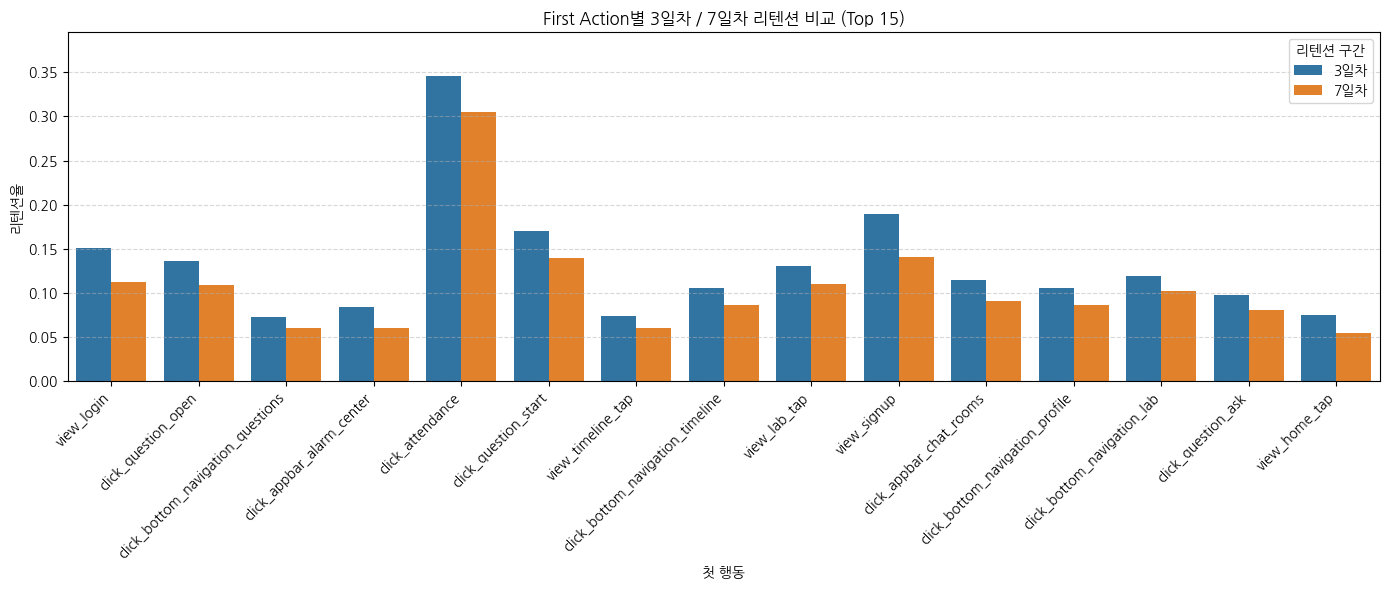

In [ ]:
# 시각화할 top 15개 액션만 추출
plot_data = retention_summary_sorted[['retention_rate_3', 'retention_rate_7']].head(15).copy()

# reset_index로 인덱스를 컬럼으로 변환
plot_data = plot_data.reset_index()

# wide → long 형태로 변환 (seaborn-friendly)
plot_data_melted = plot_data.melt(id_vars='first_meaningful_action',
                                  value_vars=['retention_rate_3', 'retention_rate_7'],
                                  var_name='retention_day',
                                  value_name='retention_rate')

# retention_day 컬럼을 보기 좋게 정리
plot_data_melted['retention_day'] = plot_data_melted['retention_day'].str.replace('retention_rate_', '') + '일차'

# 그래프 스타일 설정
plt.figure(figsize=(14, 6))
sns.barplot(data=plot_data_melted,
            x='first_meaningful_action',
            y='retention_rate',
            hue='retention_day')

# 축 설정
plt.xticks(rotation=45, ha='right')
plt.ylim(0, plot_data_melted['retention_rate'].max() + 0.05)
plt.title('First Action별 3일차 / 7일차 리텐션 비교 (Top 15)')
plt.xlabel('첫 행동')
plt.ylabel('리텐션율')
plt.legend(title='리텐션 구간')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# 리텐션 변화율 계산
retention_summary['retention_drop'] = retention_summary['retention_rate_3'] - retention_summary['retention_rate_7']
retention_summary['drop_pct'] = (retention_summary['retention_drop'] / retention_summary['retention_rate_3']).round(4)
retention_summary.sort_values('drop_pct')

,total_users_3,retained_users_3,total_users_7,retained_users_7,retention_rate_3,retention_rate_7,retention_drop,drop_pct
first_meaningful_action,,,,,,,,
click_notice_detail,36,3,36,6,0.083333,0.166667,-0.083333,-1.0000
skip_question,13,10,13,10,0.769231,0.769231,0.000000,0.0000
click_random_ask_other,16,3,16,3,0.187500,0.187500,0.000000,0.0000
click_question_share,858,174,858,160,0.202797,0.186480,0.016317,0.0805
click_attendance,6828,2357,6828,2082,0.345196,0.304921,0.040275,0.1167
complete_question,8,7,8,6,0.875000,0.750000,0.125000,0.1429
click_bottom_navigation_lab,3942,469,3942,401,0.118975,0.101725,0.017250,0.1450
view_shop,489,54,489,46,0.110429,0.094070,0.016360,0.1481
click_appbar_friend_plus,520,74,520,63,0.142308,0.121154,0.021154,0.1486


#### d. click_attendance 유저의 행동 흐름 vs view_login 유저 흐름 비교

In [ ]:
# 1. 유저 그룹 분리
attendance_users = flow_df[flow_df['first_meaningful_action'] == 'click_attendance']['user_id']
login_users = flow_df[flow_df['first_meaningful_action'] == 'view_login']['user_id']

# 2. 각 유저의 전체 이벤트 로그 추출
attendance_events = events_merged[events_merged['user_id'].isin(attendance_users)].copy()
login_events = events_merged[events_merged['user_id'].isin(login_users)].copy()

# 3. 이벤트 정렬
attendance_events.sort_values(['user_id', 'event_datetime'], inplace=True)
login_events.sort_values(['user_id', 'event_datetime'], inplace=True)

# 4. 유저별 이벤트 시퀀스 리스트화
attendance_sequences = (
    attendance_events.groupby('user_id')['event_key']
    .apply(list)
    .reset_index()
    .rename(columns={'event_key': 'event_sequence'})
)

login_sequences = (
    login_events.groupby('user_id')['event_key']
    .apply(list)
    .reset_index()
    .rename(columns={'event_key': 'event_sequence'})
)

# 5. 중복 제거 + 무의미한 행동 제거 + click_attendance 반복 방지
def clean_event_sequence(events, n=3):
    seen = set()
    cleaned = []

    for e in events:
        if e in ignore_events:
            continue
        if e == 'click_attendance' and e in seen:
            continue  # 출석 중복 제거
        if e not in seen:
            seen.add(e)
            cleaned.append(e)

    return ' → '.join(cleaned[:n]) if cleaned else 'None'

# 6. 적용: click_attendance 유저
attendance_sequences['flow'] = attendance_sequences['event_sequence'].apply(lambda x: clean_event_sequence(x, n=3))
attendance_flow_counts = attendance_sequences['flow'].value_counts().head(10)

# 7. 적용: view_login 유저
login_sequences['flow'] = login_sequences['event_sequence'].apply(lambda x: clean_event_sequence(x, n=3))
login_flow_counts = login_sequences['flow'].value_counts().head(10)

# 8. 결과 출력
print("\n[click_attendance 유저 상위 행동 흐름]")
print(attendance_flow_counts)

print("\n[view_login 유저 상위 행동 흐름]")
print(login_flow_counts)


[click_attendance 유저 상위 행동 흐름]
flow
click_attendance → click_question_start → skip_question                    566
click_attendance → click_appbar_alarm_center → click_notice_detail         507
click_attendance → click_bottom_navigation_lab → view_lab_tap              260
click_attendance → click_bottom_navigation_profile → view_lab_tap          259
click_attendance → view_lab_tap → click_bottom_navigation_lab              253
click_attendance → click_bottom_navigation_timeline → view_timeline_tap    233
click_attendance → click_question_start → complete_question                232
click_attendance → view_lab_tap → click_bottom_navigation_profile          217
click_attendance → view_timeline_tap → click_bottom_navigation_timeline    190
click_attendance → click_question_open → view_timeline_tap                 170
Name: count, dtype: int64

[view_login 유저 상위 행동 흐름]
flow
view_login → click_appbar_alarm_center → click_notice_detail                         2921
view_login → click_bottom_

##### 전체 기간이 아닌 하루 단위로 분석

In [ ]:
# 하루 단위로 유저의 행동 시퀀스 구성
# event_datetime에서 날짜만 추출
events_merged['event_date'] = events_merged['event_datetime'].dt.date

# 유저 x 날짜별 이벤트 리스트
# 유저 아이디별로 이벤트를 시간 순서대로 리스트로 정리
daily_flows = (
    events_merged
    .sort_values(['user_id', 'event_datetime'])
    .groupby(['user_id', 'event_date'])['event_key']
    .apply(list)
    .reset_index()
)

# 무의미한 이벤트 제거, 중복 이벤트 제거 (같은 이벤트 반복 클릭), 최대 앞에서부터 3개까지만 추출
def clean_sequence(events, n=3):
    seen = set()
    cleaned = []
    for e in events:
        if e in ignore_events:
            continue
        if e not in seen:
            seen.add(e)
            cleaned.append(e)
    return ' → '.join(cleaned[:n]) if cleaned else 'None'

# 하루 단위 흐름 적용
daily_flows['flow'] = daily_flows['event_key'].apply(lambda x: clean_sequence(x, n=3))

# 특정 유저 그룹 (출석 유저)만 필터링
attendance_users = flow_df[flow_df['first_meaningful_action'] == 'click_attendance']['user_id']
daily_attendance_flows = daily_flows[daily_flows['user_id'].isin(attendance_users)]

# 출석 유저들의 상위 행동 흐름 집계
attendance_flow_counts = daily_attendance_flows['flow'].value_counts().head(10)

In [ ]:
# 'view_login'을 첫 meaningful action으로 한 유저만 필터링
login_users = flow_df[flow_df['first_meaningful_action'] == 'view_login']['user_id']

# 해당 유저들의 하루 단위 행동 흐름만 추출
daily_login_flows = daily_flows[daily_flows['user_id'].isin(login_users)]

# 가장 많이 나타난 하루 단위 행동 흐름 상위 10개 집계
login_flow_counts = daily_login_flows['flow'].value_counts().head(10)

# 8. 결과 출력
print("\n[click_attendance 유저의 하루 단위 행동 흐름 TOP 10]")
print(attendance_flow_counts)

print("\n[view_login 유저의 하루 단위 행동 흐름 TOP 10]")
print(login_flow_counts)


[click_attendance 유저의 하루 단위 행동 흐름 TOP 10]
flow
click_attendance                                                           14002
None                                                                        3741
click_attendance → click_question_start → skip_question                     2736
click_attendance → click_question_open                                      1342
click_attendance → view_timeline_tap → view_lab_tap                         1259
click_attendance → click_bottom_navigation_timeline → view_timeline_tap     1071
click_attendance → click_appbar_alarm_center → click_notice_detail          1024
click_attendance → click_question_start → complete_question                  980
click_attendance → view_timeline_tap → click_bottom_navigation_timeline      955
click_question_start → skip_question → complete_question                     799
Name: count, dtype: int64

[view_login 유저의 하루 단위 행동 흐름 TOP 10]
flow
None                                                                      

- 로그인 유저는 절반 이상이 행동 없이 이탈
    - 소극적 탐색 또는 진입 후 이탈 경향 강함
    - 구조적으로 참여 유도 부족, 리텐션 낮을 수밖에 없음
    
- 출석 유저는 대부분 의미 있는 행동을 하고 있음

### 3-5. 행동 유형별 클러스터링

클러스터별 유저 수:
cluster
0    224266
1        94
2       186
3      6211
Name: count, dtype: int64


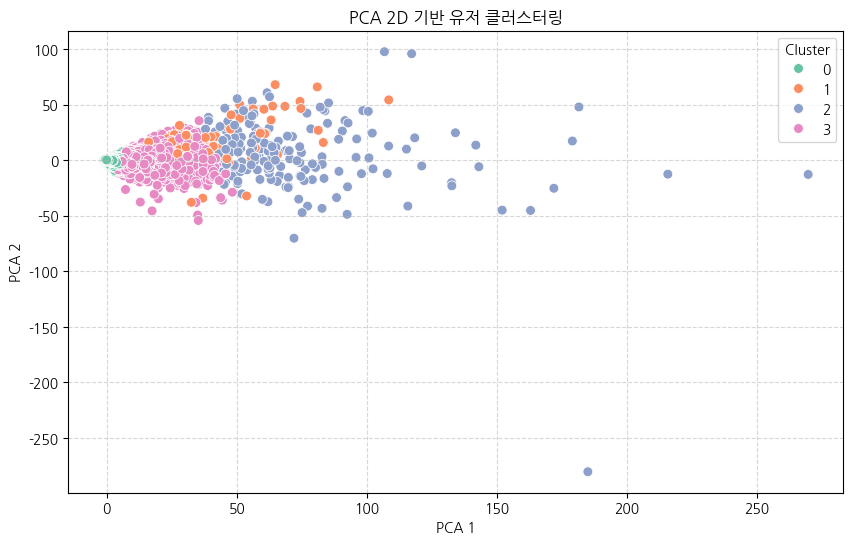

In [ ]:
# 1. 유저별 행동 데이터를 피벗 형태로 변환
# 각 유저가 어떤 이벤트(event_key)를 몇 번 했는지를 세어 벡터화
user_event_matrix = (
    events_merged
    .groupby(['user_id', 'event_key'])
    .size()  # 유저-이벤트 조합별 횟수 계산
    .unstack(fill_value=0)  # 유저별 행, 이벤트별 열로 pivot / 없으면 0으로 채움
)

# 2. 스케일 표준화 (정규화)
# 유저마다 전체 행동량이 다르기 때문에, 평균 0, 표준편차 1로 정규화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(user_event_matrix)  # ndarray 형태로 반환됨

# 3. KMeans 클러스터링 적용 (군집 수는 4개로 가정, 필요 시 elbow method 등으로 튜닝)
kmeans_2 = KMeans(n_clusters=4, random_state=42)
clusters_2 = kmeans_2.fit_predict(X_scaled)

# 4. 클러스터 결과를 user_event_matrix에 컬럼으로 추가
user_event_matrix['cluster'] = clusters_2

# 5. 클러스터별 평균 행동 패턴 확인
# 각 클러스터에 속한 유저들의 평균 이벤트 발생 횟수를 비교함
cluster_profiles = user_event_matrix.groupby('cluster').mean()

# 6. 클러스터별 유저 수 확인 (해석 시 참고)
cluster_counts = user_event_matrix['cluster'].value_counts().sort_index()

print("클러스터별 유저 수:")
print(cluster_counts)

# 시각화를 위해 DataFrame으로 변환
pca_2 = PCA(n_components=2)
pca_matrix_2 = pca_2.fit_transform(X_scaled)   # ← 시각화 전용

pca_df = pd.DataFrame(pca_matrix_2, columns=['PCA1', 'PCA2'])
pca_df['cluster'] = clusters_2

# 8. 시각화 (PCA 결과를 통해 군집이 얼마나 구분되는지 보기)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=pca_df, x='PCA1', y='PCA2', hue='cluster', palette='Set2', s=50)
plt.title("PCA 2D 기반 유저 클러스터링")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title='Cluster')
plt.grid(linestyle='--', alpha=0.5)
plt.show()
plt.show()

- Cluster 2는 다양한 행동 -> 퍼져 있음
- Cluster 0, Cluster 3은 행동 유사 -> 밀집됨

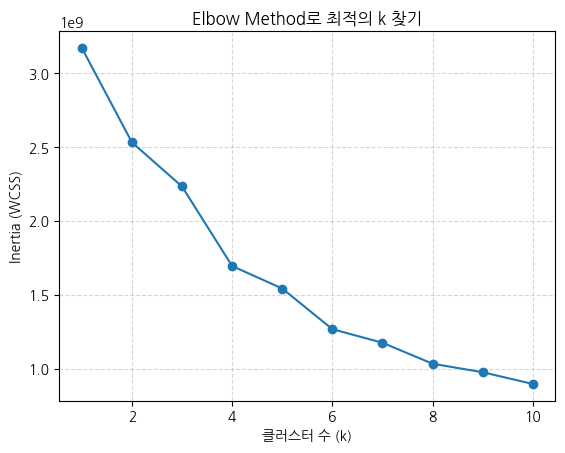

In [ ]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(user_event_matrix)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel('클러스터 수 (k)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method로 최적의 k 찾기')
plt.grid(linestyle='--', alpha=0.5)
plt.show()

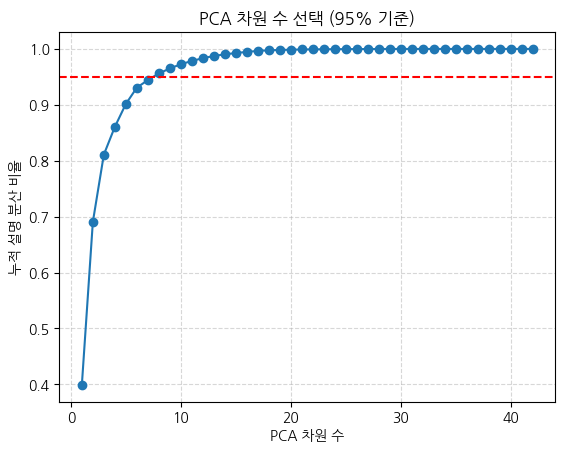

In [ ]:
pca = PCA()
pca.fit(user_event_matrix)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.axhline(y=0.95, color='r', linestyle='--')
plt.xlabel('PCA 차원 수')
plt.ylabel('누적 설명 분산 비율')
plt.title('PCA 차원 수 선택 (95% 기준)')
plt.grid(linestyle='--', alpha=0.5)
plt.show()


In [ ]:
# PCA - 누적 설명 분산 기준 95%로 차원 축소
pca_95 = PCA(n_components=0.95, random_state=42)
X_pca_95 = pca_95.fit_transform(user_event_matrix)

print(f"선택된 PCA 차원 수: {pca_95.n_components_}")  # 몇 개로 줄였는지 확인

# 최적 k(4)로 KMeans 클러스터링
kmeans_final = KMeans(n_clusters=4, random_state=42)
cluster_labels = kmeans_final.fit_predict(X_pca_95)

# 클러스터 품질 평가 지표: 실루엣 점수
sil_score = silhouette_score(X_pca_95, cluster_labels)
print(f"Silhouette Score: {sil_score:.4f}")

# 원래 유저-이벤트 행렬에 클러스터 라벨 추가
user_event_matrix['cluster'] = cluster_labels

선택된 PCA 차원 수: 8
Silhouette Score: 0.9161


클러스터별 유저 수:
cluster
0    219647
1        74
2       810
3     10226
Name: count, dtype: int64


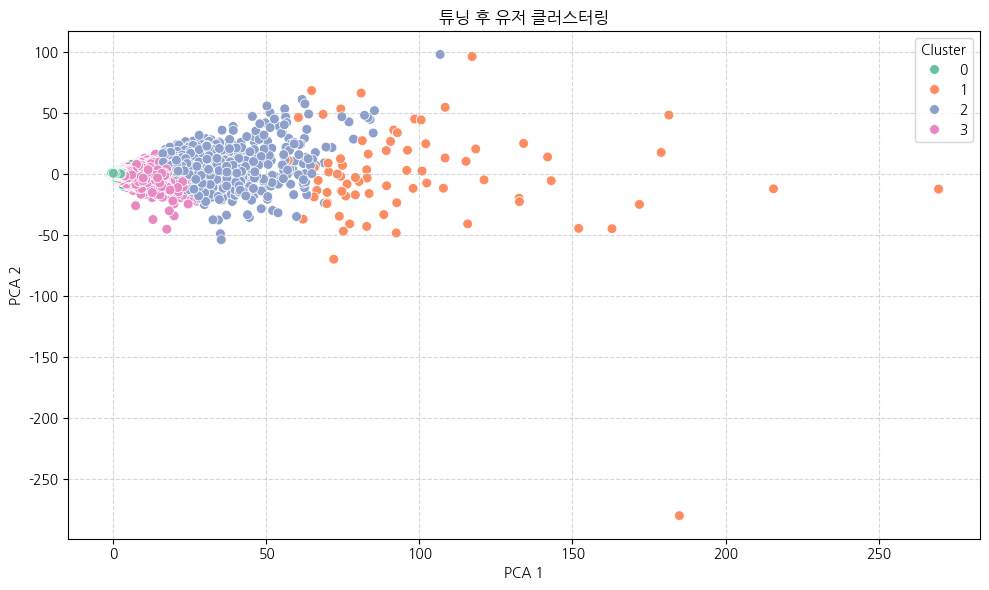

In [ ]:
# 1. 유저별 행동 데이터를 피벗 형태로 변환
user_event_matrix = (
    events_merged
    .groupby(['user_id', 'event_key'])
    .size()
    .unstack(fill_value=0)
)

# 2. 표준화
scaler = StandardScaler()
scaled_matrix = scaler.fit_transform(user_event_matrix)

# 3. PCA 차원 축소 (그래프 결과: 약 10~11차원에서 95% 설명)
pca_8 = PCA(n_components=8)  # <- 변경된 부분
pca_matrix_8 = pca_8.fit_transform(scaled_matrix)

# 4. KMeans 클러스터링 (Elbow 결과: k=4)
kmeans_4 = KMeans(n_clusters=4, random_state=42)
clusters_4 = kmeans_4.fit_predict(pca_matrix_8)  # <- PCA 결과로 클러스터링

# 5. 결과 저장
user_event_matrix['cluster'] = clusters_4

# 6. 클러스터별 평균 행동 패턴
cluster_profiles = user_event_matrix.groupby('cluster').mean()
cluster_counts = user_event_matrix['cluster'].value_counts().sort_index()

print("클러스터별 유저 수:")
print(cluster_counts)

# 7. PCA 2차원 시각화
pca_2d = PCA(n_components=2)
pca_result = pca_2d.fit_transform(pca_matrix_8)  # 이미 축소된 데이터에서 다시 2D로 축소

pca_df = pd.DataFrame(pca_result, columns=['PCA1', 'PCA2'])
pca_df['cluster'] = clusters_4

plt.figure(figsize=(10, 6))
sns.scatterplot(data=pca_df, x='PCA1', y='PCA2', hue='cluster', palette='Set2', s=50)
plt.title("튜닝 후 유저 클러스터링")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title='Cluster')
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
# 튜닝 전
sil_before = silhouette_score(pca_matrix_2, clusters_2)
ch_before = calinski_harabasz_score(pca_matrix_2, clusters_2)

# 튜닝 후
sil_after = silhouette_score(pca_matrix_8, clusters_4)
ch_after = calinski_harabasz_score(pca_matrix_8, clusters_4)

print(f"\n튜닝 전 Silhouette: {sil_before:.4f}")
print(f"\n튜닝 후 Silhouette: {sil_after:.4f}")

print(f"\n튜닝 전 CH Score: {ch_before:.2f}")
print(f"\n튜닝 후 CH Score: {ch_after:.2f}")


튜닝 전 Silhouette: 0.8851

튜닝 후 Silhouette: 0.8288

튜닝 전 CH Score: 112766.23

튜닝 후 CH Score: 53970.83


In [ ]:
# 무의미한 이벤트 정의
ignore_events = [
    '$session_start', '$session_end', 'launch_app',
    'view_login', 'view_signup', 'view_home_tap'
]

# 1. 무의미 이벤트 제거
filtered_event_keys = [col for col in user_event_matrix.columns if col not in ignore_events and col != 'cluster']
user_event_matrix_filtered = user_event_matrix[filtered_event_keys]

# 2. 클러스터 라벨 추가 (튜닝 전 결과)
user_event_matrix_filtered = user_event_matrix_filtered.assign(cluster=clusters_2)

# 3. 클러스터별 평균 행동 벡터 계산
cluster_profiles = user_event_matrix_filtered.groupby('cluster').mean()

# 4. 클러스터별 상위 10개 행동 보기
top10_actions = cluster_profiles.T.apply(lambda x: x.sort_values(ascending=False).head(10))
display(top10_actions)

cluster,0,1,2,3
event_key,,,,
click_appbar_alarm_center,NaN,181.882979,NaN,NaN
click_appbar_chat_rooms,NaN,NaN,192.419355,NaN
click_bottom_navigation_lab,2.529728,NaN,NaN,31.090968
click_bottom_navigation_profile,3.486008,122.095745,309.672043,47.145065
click_bottom_navigation_questions,4.139607,143.989362,359.596774,47.055064
click_bottom_navigation_timeline,2.930792,NaN,245.709677,35.419739
click_notice_detail,NaN,356.010638,NaN,NaN
click_question_open,4.057610,575.872340,487.887097,68.271937
click_question_share,NaN,374.521277,NaN,NaN


#### a. 클러스터별 특징 해석

1. Cluster 0: 전반적으로 낮은 활동 + 타임라인/프로필 소비
    - 주요 행동:
        - view_lab_tab, view_timeline_tap, click_bottom_navigation_profile
        - skip_question과 click_question_open도 일부 있음
    - 해석:
        - 가볍게 탐색만 하는 유저들, 질문에는 거의 참여하지 않음
        - 콘텐츠만 소비하는 '관망형 유저'

2. Cluster 1: 알림과 공지 열람 집중
    - 주요 행동:
        - click_appbar_alarm_center, click_notice_detail, click_question_share, click_question_open
    - 해석:
        - 알림 클릭 -> 공지 확인 -> 콘텐츠 공유까지 이뤄지는 구조
        - 관리자 공지나 친구 요청을 자주 확인하는 '공지 확인형 유저'

3. Cluster 2: 질문, 투표, 타임라인까지 고루 이용
    - 주요 행동:
        - click_question_start, click_question_open, skip_question, view_lab_tap, click_bottom_navigation_questions
        - click_random_ask_shuffle, click_bottom_navigation_timeline
    - 해석:
        - 질문 참여 + 다양한 탭 이동 + 활동성 높은 유저
        - 핵심 유저에 가까운 '핵심 참여형'

4. Cluster 3: 프로필/타임랑니 중심의 중간 유저
    - 주요 행동:
        - click_bottom_navigation_profile, click_bottom_navigation_timeline, view_timeline_tap, view_lab_tap, click_question_open
    - 해석:
        - 질문보다는 다른 사람의 활동/프로필 확인에 초점
        - 관심은 있지만 행동 전환까지는 이르지 않은 '관찰형 중간 유저'